# Nimotuzumab PopPK: reproducible review

## Answer
Absolute exposure and paired dose ratios depend on structure, but candidate complexity is not stably identified. No bootstrap confidence interval or clinical dose decision is supported. This notebook runs without patient-level data or RDS. Full R estimation commands are in README; cached aggregate review is not described as refitting.

In [1]:
from pathlib import Path
import json,hashlib,pandas as pd,numpy as np
R=Path('.')
for f,h in json.loads((R/'output-hashes.json').read_text()).items():
    assert hashlib.sha256((R/f).read_bytes()).hexdigest()==h,f
print('All distributed aggregate/reference/figure hashes match')

All distributed aggregate/reference/figure hashes match


## Internal predictive diagnostics and failed uncertainty estimation
12 held-out subjects per model; subject-average metrics. An extra optimizer sensitivity is retained. Finite estimates are not convergence success. Original selection-after-fit and convergence limitations remain.

In [2]:
l=pd.read_csv('a03/loso-summary.csv');l['improvement_percent']=100*(1-l.RMSE/l.loc[l.model=='M1','RMSE'].iloc[0]);display(l)
display(pd.read_csv('a03/loso-integration-check.csv'))
b=pd.read_csv('a03/bootstrap-summary.csv');display(b)
assert b.attempted.sum()==800 and not b.CI_defensible.any()
assert pd.read_csv('a03/bootstrap-CI.csv').empty
assert pd.read_csv('a03/bootstrap-typical-exposure-CI.csv').empty
assert len(pd.read_csv('a03/profiles.csv'))==14

,model,MSE,coverage,mean_lpd,RMSE,improvement_percent
0,M1,1.015900,0.918573,-1.385789,0.945822,0.000000
1,M2,0.939822,0.921787,-1.346688,0.906147,4.194683
2,M3,0.929394,0.918930,-1.332399,0.914719,3.288434


,model,RMSE,coverage,mean_lpd,RMSE_improvement_percent
0,M1,0.945055,0.915368,-1.384423,0.000000
1,M2,0.906311,0.924764,-1.343507,4.099652
2,M3,0.915147,0.921906,-1.330276,3.164599


,group,attempted,finite,qualified,qualified_rate,CI_defensible
0,M1,200,200,9,0.045,False
1,M2,200,200,9,0.045,False
2,M3,200,200,11,0.055,False
3,nlminb-M1,200,200,44,0.220,False


## Dose exposure and ratios
10000 paired virtual individuals per model and scenario. IIV is conditional on fixed population parameter estimates; no residual error is added to exposure simulations. Model-to-model random seeds do not establish a biological individual match.

In [3]:
e=pd.read_csv('a03/exposure.csv');rr=pd.read_csv('a03/paired-ratios.csv')
assert len(e)==168 and len(rr)==168
q=rr[(rr.endpoint=='AUC')&(rr.cycle=='tenth')&rr.scenario.str.startswith('dose-')]
display(q)
for m in ['M1','M2']:
    for dose in [50,100,200,400]:
        z=rr[(rr.model==m)&(rr.scenario==f'dose-{dose}')][['p10','median','p90']]
        assert np.max(abs(z.to_numpy()-dose/200))<1e-8
display(e[(e.endpoint=='AUC')&(e.cycle=='tenth')&e.scenario.str.startswith('dose-')])

,model,scenario,cycle,endpoint,p10,median,p90
4,M1,dose-50,tenth,AUC,0.250000,0.250000,0.250000
12,M1,dose-100,tenth,AUC,0.500000,0.500000,0.500000
20,M1,dose-200,tenth,AUC,1.000000,1.000000,1.000000
28,M1,dose-400,tenth,AUC,2.000000,2.000000,2.000000
60,M2,dose-50,tenth,AUC,0.250000,0.250000,0.250000
68,M2,dose-100,tenth,AUC,0.500000,0.500000,0.500000
76,M2,dose-200,tenth,AUC,1.000000,1.000000,1.000000
84,M2,dose-400,tenth,AUC,2.000000,2.000000,2.000000
116,M3,dose-50,tenth,AUC,0.198558,0.214113,0.238408
124,M3,dose-100,tenth,AUC,0.430017,0.452409,0.485085


,model,scenario,amount_mg,interval_h,infusion_h,cycle,endpoint,p10,median,p90
4,M1,dose-50,50,168,0.5,tenth,AUC,3102.264416,5781.161829,10460.707388
12,M1,dose-100,100,168,0.5,tenth,AUC,6204.528832,11562.323658,20921.414776
20,M1,dose-200,200,168,0.5,tenth,AUC,12409.057663,23124.647316,41842.829551
28,M1,dose-400,400,168,0.5,tenth,AUC,24818.115326,46249.294633,83685.659102
60,M2,dose-50,50,168,0.5,tenth,AUC,3106.545141,6213.108111,9010.289102
68,M2,dose-100,100,168,0.5,tenth,AUC,6213.090283,12426.216222,18020.578203
76,M2,dose-200,200,168,0.5,tenth,AUC,12426.180566,24852.432444,36041.156406
84,M2,dose-400,400,168,0.5,tenth,AUC,24852.361131,49704.864887,72082.312813
116,M3,dose-50,50,168,0.5,tenth,AUC,2891.302488,5904.859867,7085.823352
124,M3,dose-100,100,168,0.5,tenth,AUC,5878.502970,12476.726473,15337.470660


## Independent M1 propagation from distributed estimates
The next cell recreates a typical 200 mg, 0.5 h infusion, 168 h interval, tenth-dose AUC using an analytic one-compartment infusion sum. It checks a mathematical model property independently of the saved exposure quantiles. It does not estimate patient parameters.

In [4]:
f=pd.read_csv('snapshots/M1/fixed-estimates.csv').set_index('parameter').estimate
CL,V=np.exp(f.tcl),np.exp(f.tv);k=CL/V
t=np.unique(np.r_[np.linspace(1512,1680,673),1512.5]);c=np.zeros_like(t)
for start in np.arange(10)*168:
    dt=np.maximum(t-start,0);during=np.minimum(dt,.5)
    c+=400/CL*(-np.expm1(-k*during))*np.exp(-k*np.maximum(dt-.5,0))
auc=np.trapezoid(c,t)
print('Independent typical M1 tenth AUC (ug h/mL):',round(auc,3))
assert 22000<auc<24000
display(pd.read_csv('a03/independent-prediction-checks.csv'))
display(pd.read_csv('a03/numerical-QA.csv'))

Independent typical M1 tenth AUC (ug h/mL): 23170.17


,model,run,max_absolute_log_prediction_difference
0,M1,baseline,0.000003
1,M1,infusion-0.5h,0.000003
2,M1,allometry-fixed,0.000003
3,M2,baseline,0.000002
4,M2,infusion-0.5h,0.000003
5,M2,allometry-fixed,0.000002
6,M3,baseline,0.000003
7,M3,infusion-0.5h,0.000003
8,M3,allometry-fixed,0.000003


,model,max_relative_AUC_grid_change
0,M1,3.595689e-07
1,M2,3.550950e-07
2,M3,3.552879e-07


## Figures
Captions and units are in article.md. Figure generation from patient-level GOF tables is deliberately excluded from this data-free review; the original analysis retains executable figure code and full inputs. Generated figures are included as derived outputs.

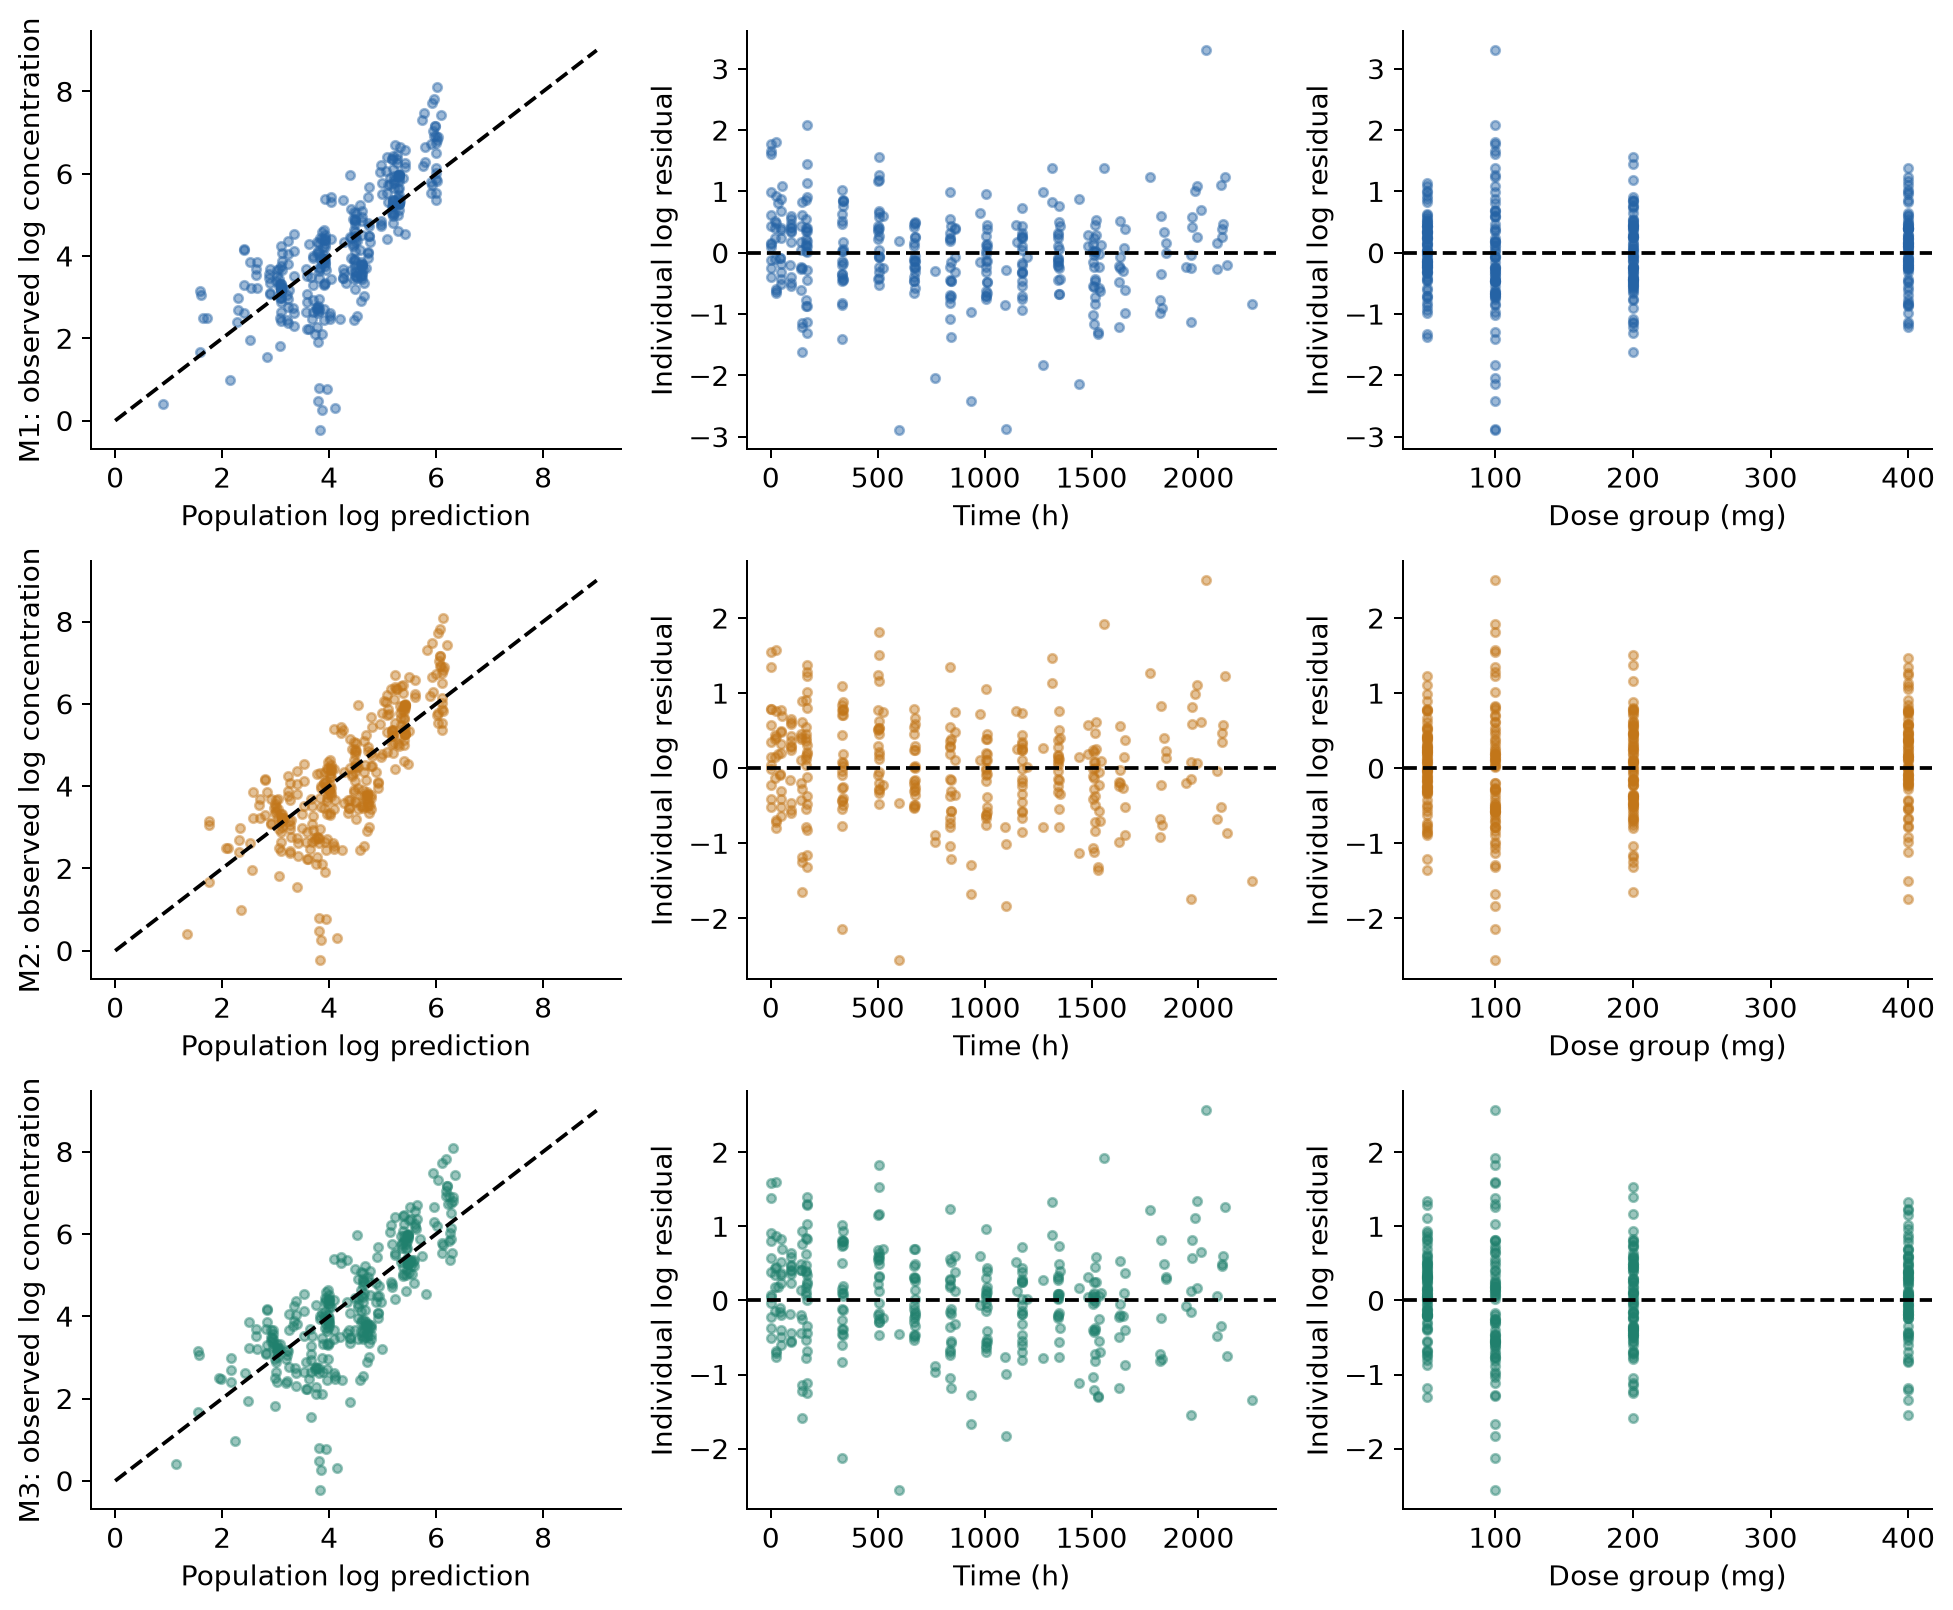

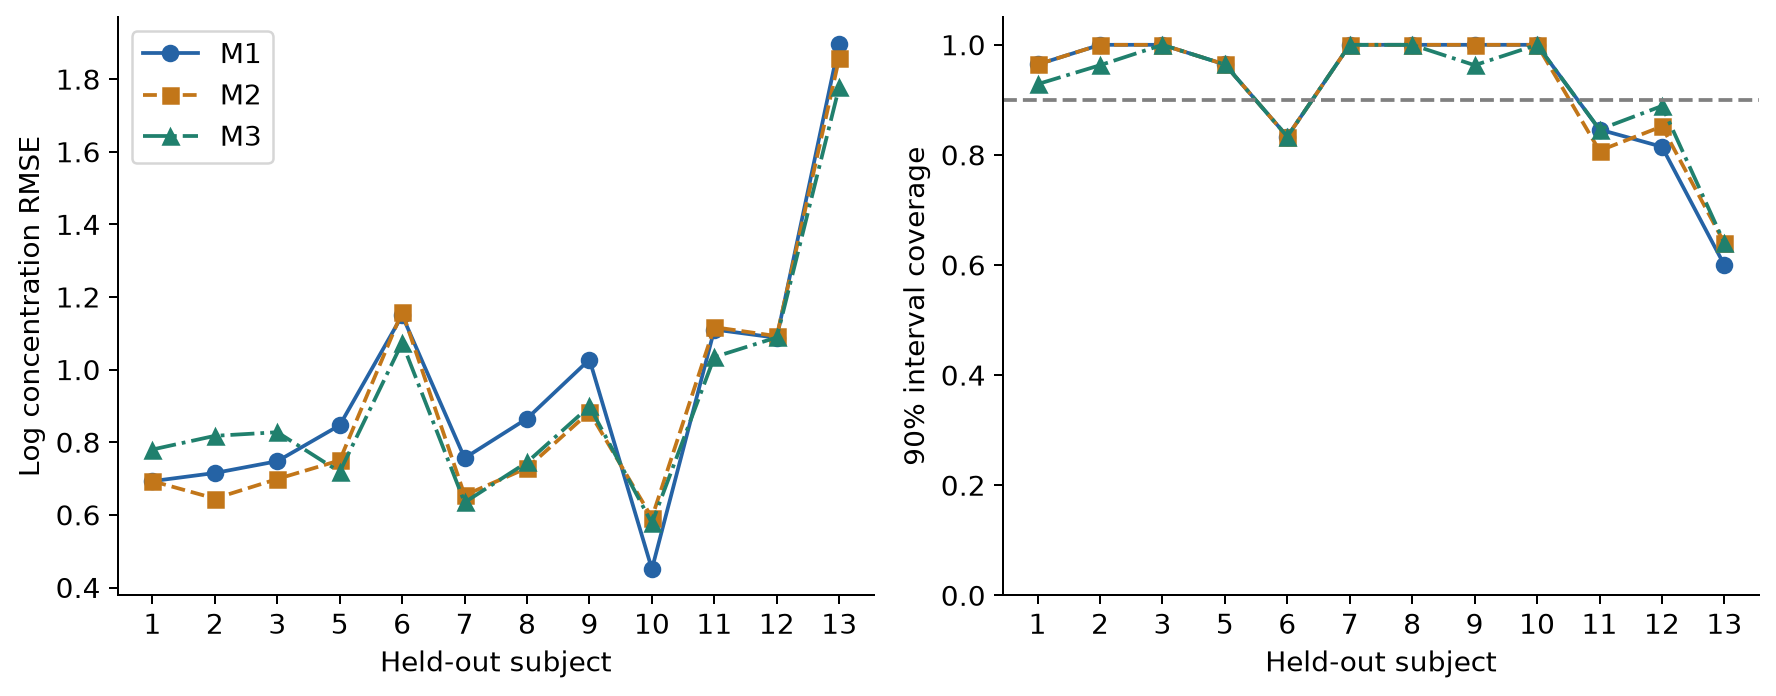

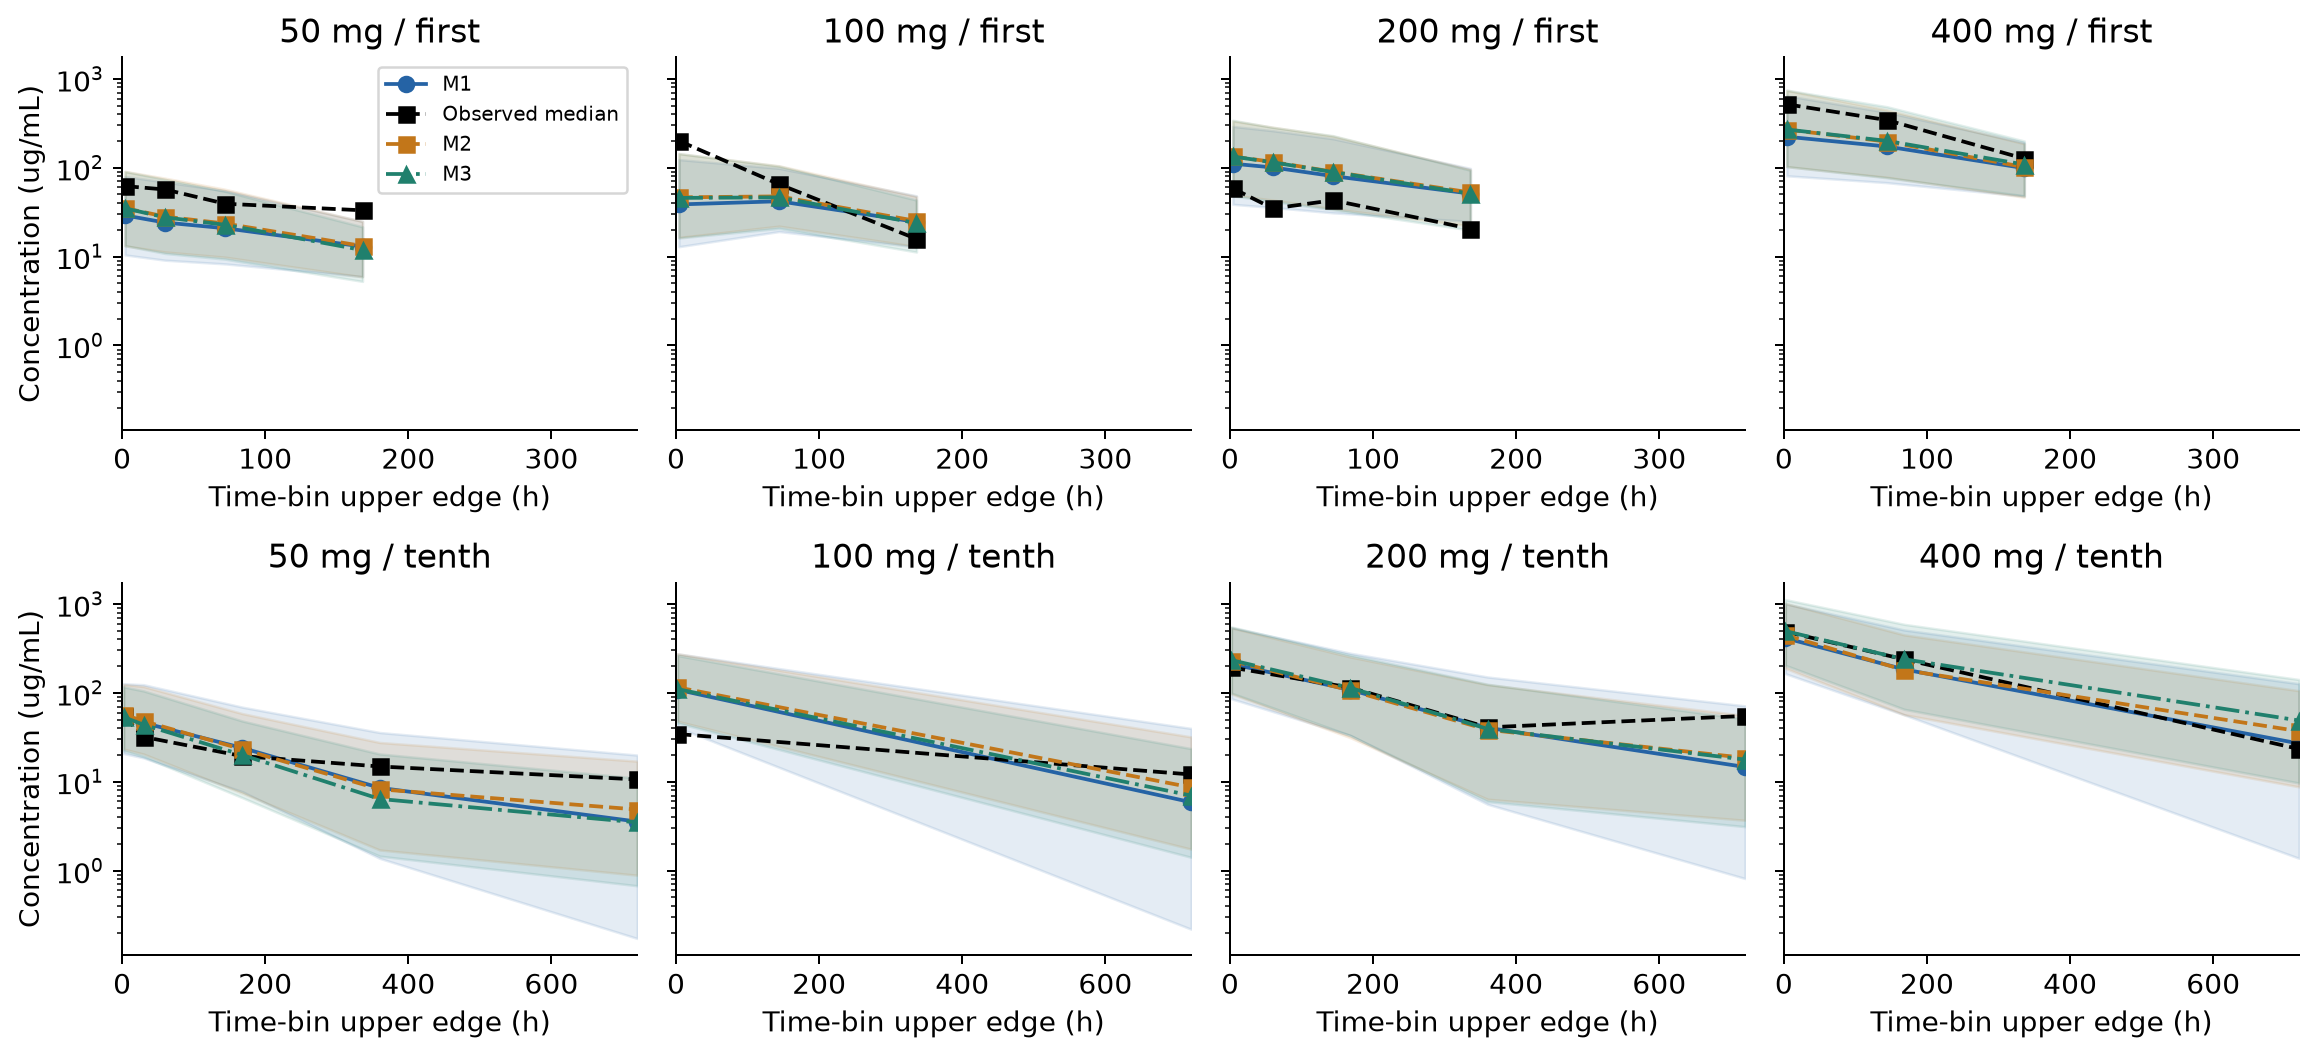

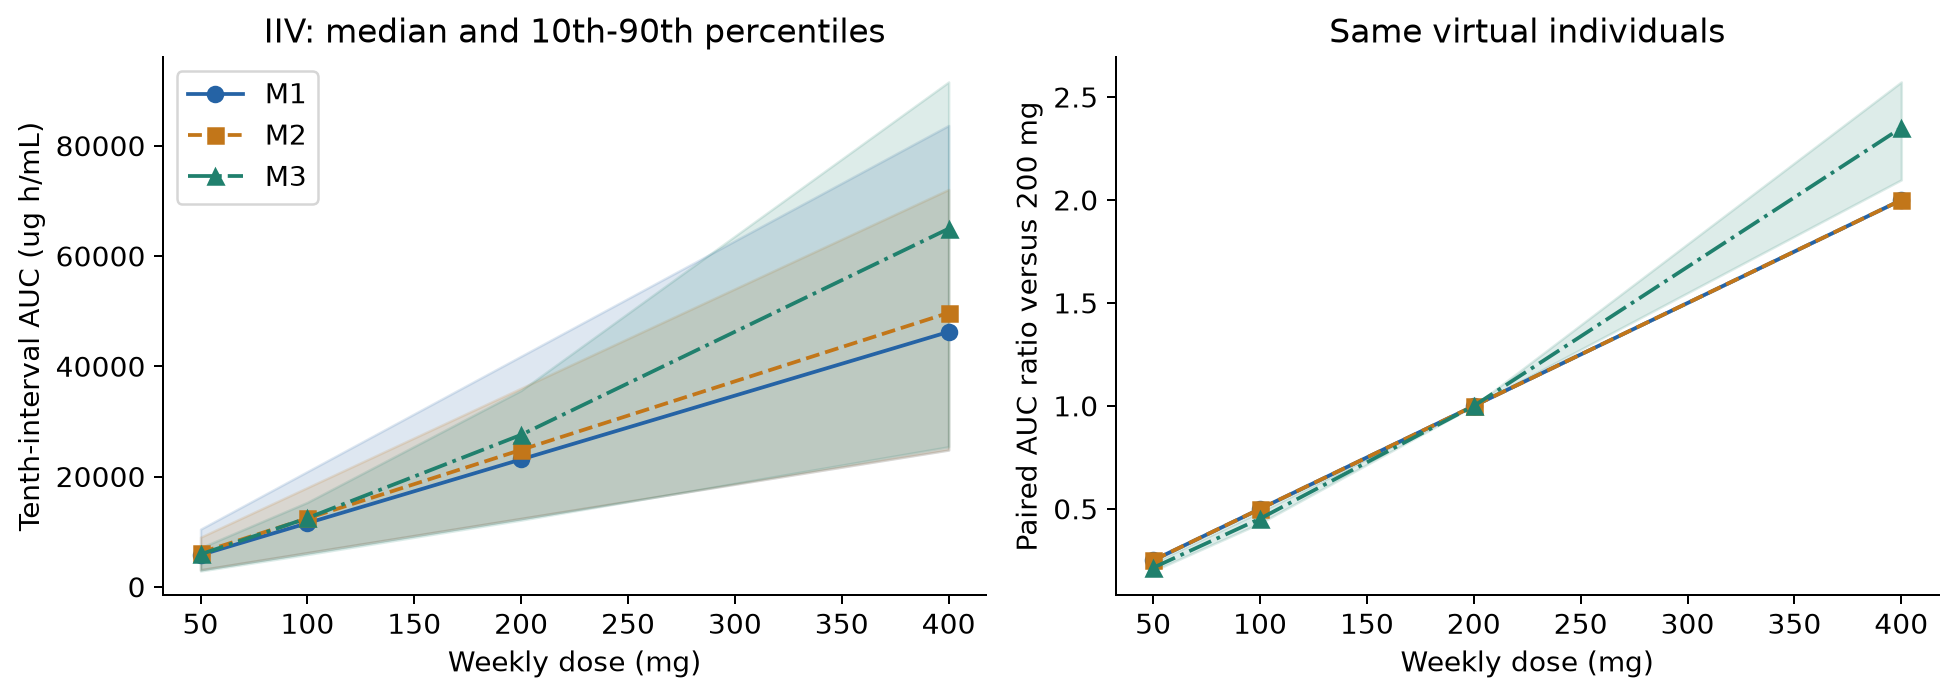

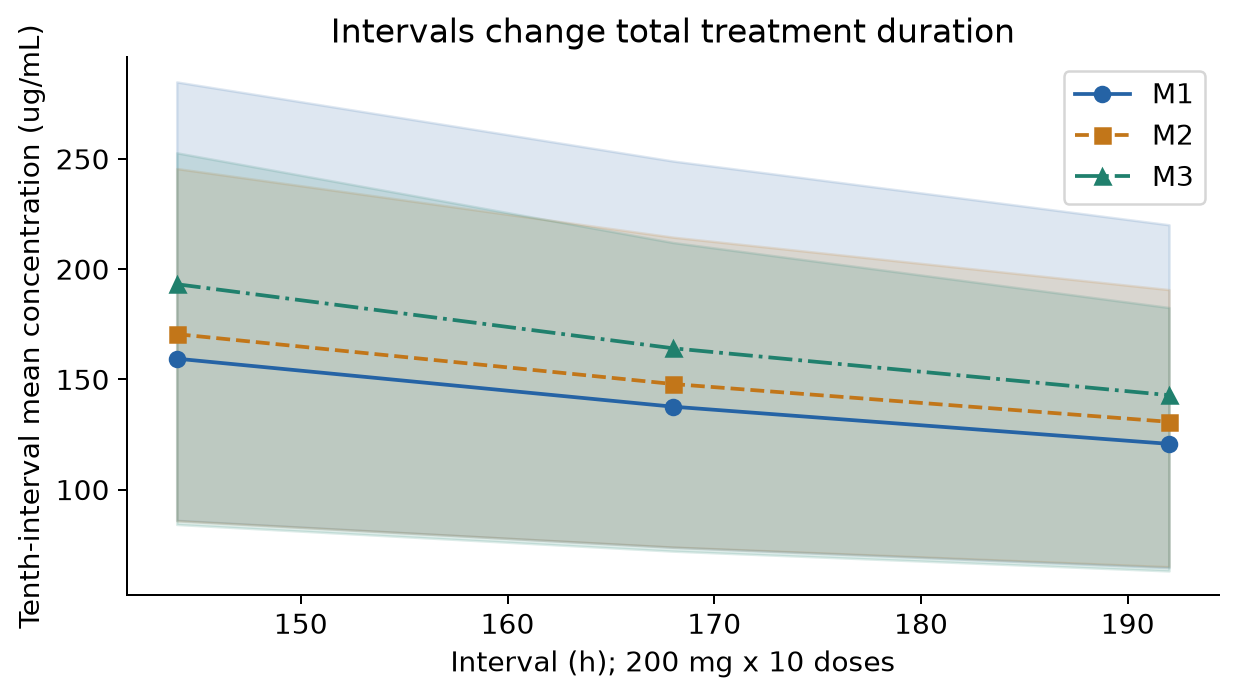

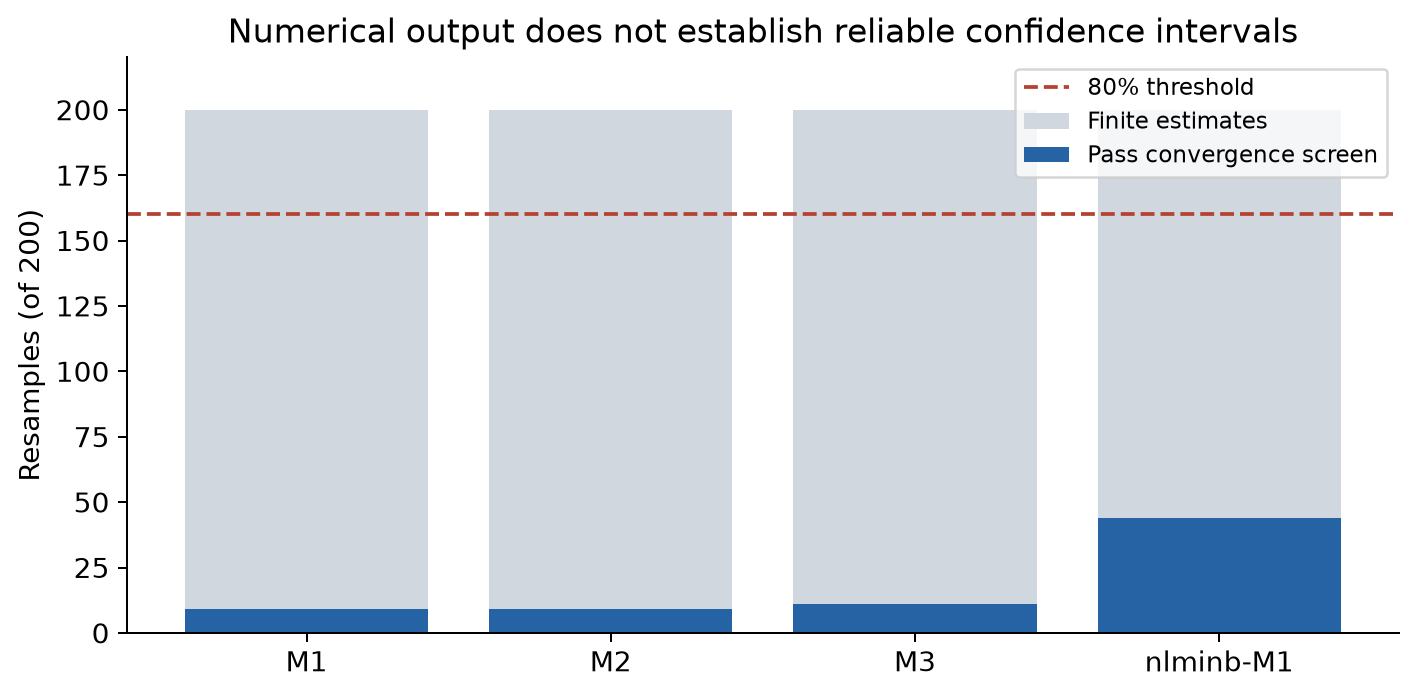

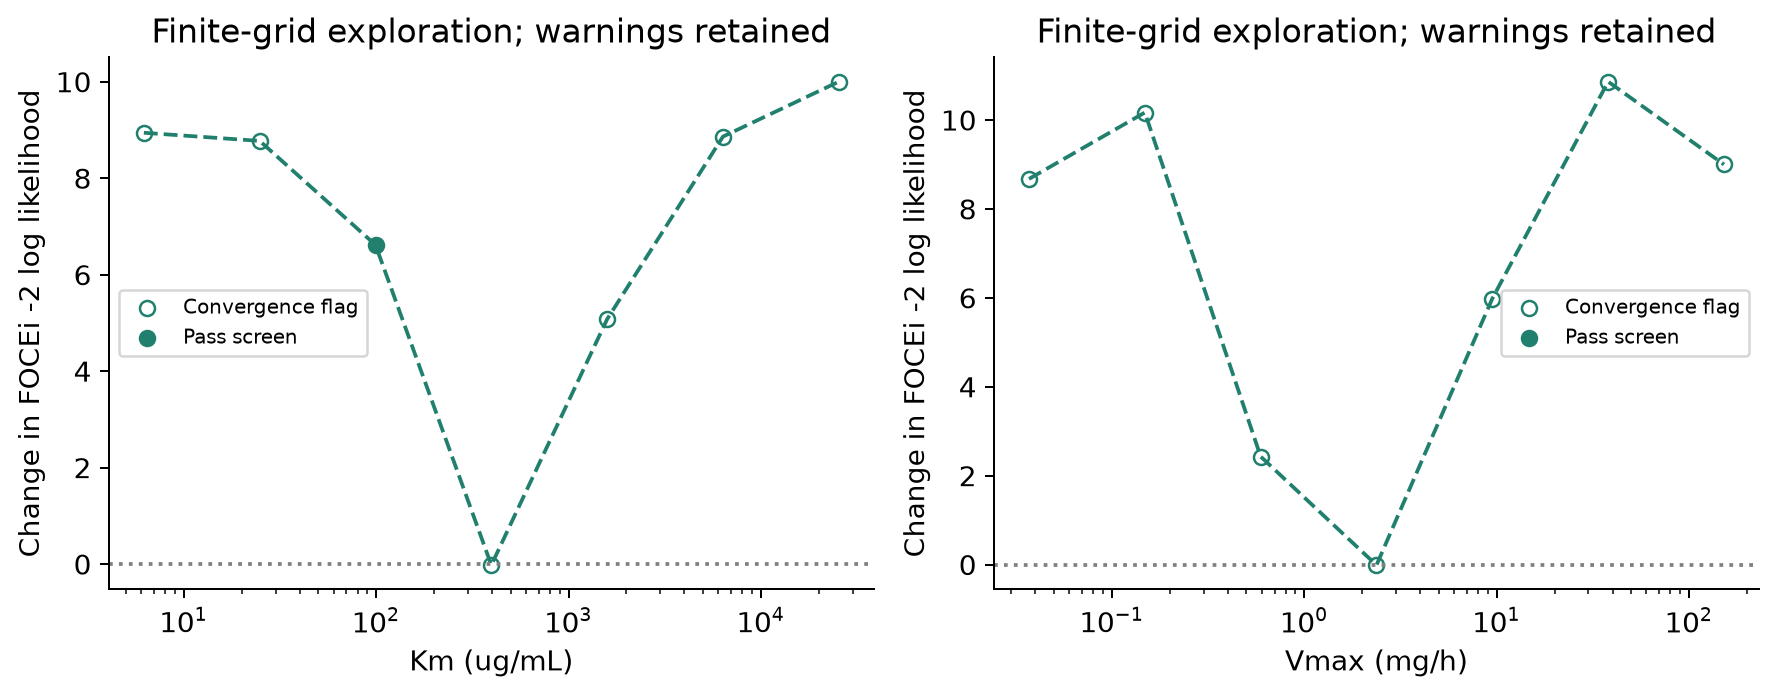

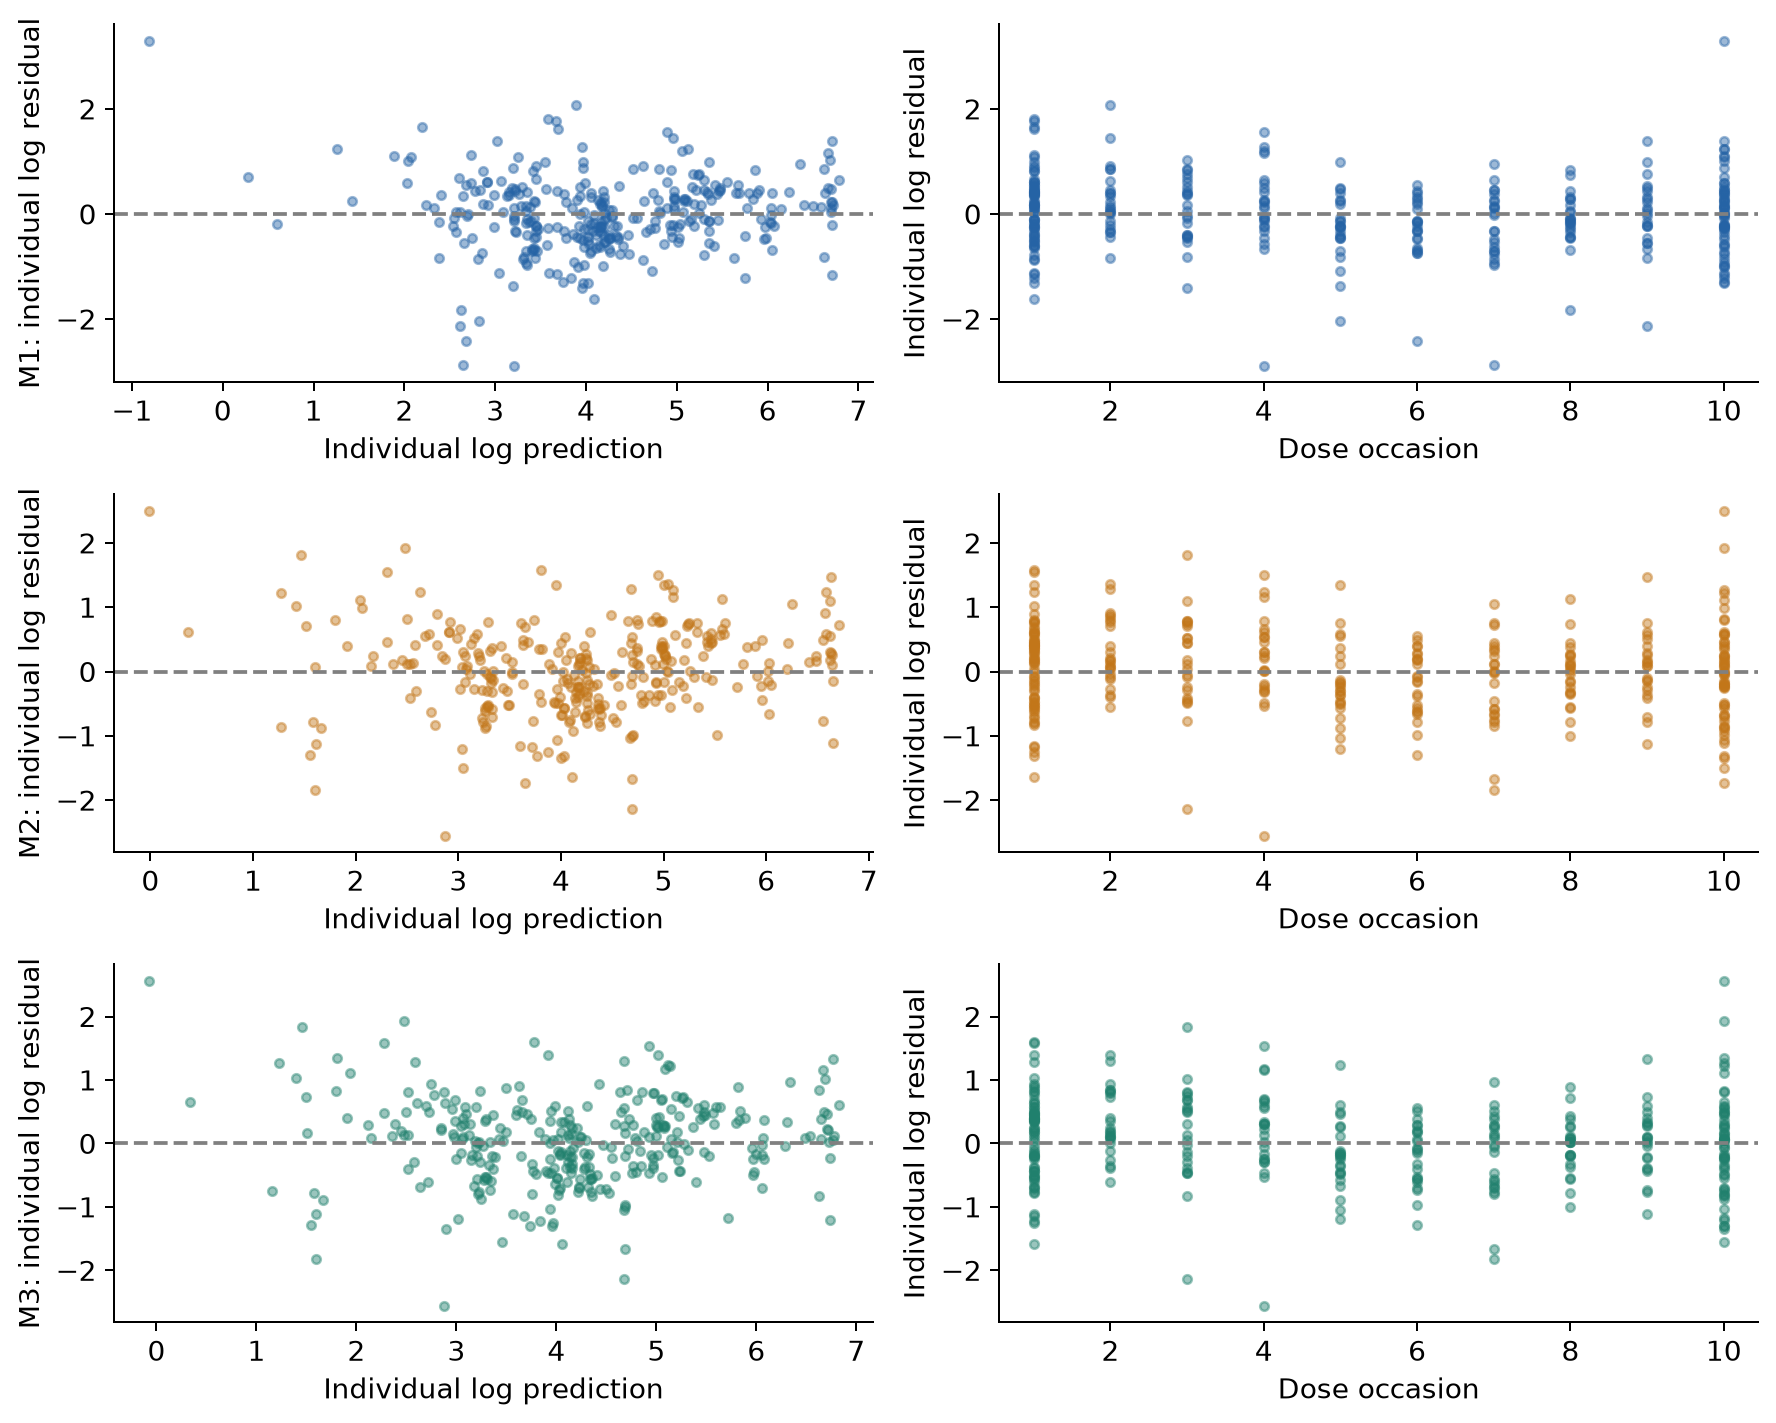

In [5]:
from IPython.display import Image,display
for f in sorted(Path('a03/figures').glob('*.png')):
    display(Image(filename=str(f)))

## Interpretation
Read article.md and README. No patient-level table is distributed. The companion accompanies the research article. The bootstrap screening threshold fails; successful-subset percentiles are withheld. More data and resolved input provenance are needed before asserting a minimal adequate structure.